# SHOWROOM ANALYTICS

### Exploratory Data Analysis

This notebook explores showroom sales transactions to understand:

- Revenue realization
- Revenue drivers
- Branch performance
- Customer and transaction behavior
- Trade-In behavior
- Sales trends

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## 01. Import Libraries

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

## 02. Load Dataset

The dataset contains 10,000 showroom sales transactions recorded throughout 2025.

In [127]:
url = "https://raw.githubusercontent.com/auliaazza/showroom-analytics/main/data/showroom_mobil_clean.csv"

df = pd.read_csv(url)

df.head()

,sales_date,order_id,customer_name,branch,product_name,category,color,price,quantity,payment_type,trade_in,trade_in_status,discount,total,total_sales,status,branch_address,city
0,12/13/2025,TRX00001,Customer_913,Jakarta,Daihatsu Xenia 1.5 R CVT,MPV,Silver Metalik,240000000,1,Cash + Trade In,74000000,Trade In,0,240000000,166000000,completed,Jl. MT. Haryono No. 12,Jakarta
1,10/15/2025,TRX00002,Customer_261,Jakarta,Toyota Rush 1.5 S GR Sport CVT,SUV,Hitam Metalik,300000000,1,Kredit,0,Non Trade In,0,300000000,300000000,completed,Jl. MT. Haryono No. 12,Jakarta
2,1/4/2025,TRX00003,Customer_4465,Kendari,Honda BR-V 1.5 E CVT,MPV,Merah,310000000,1,Kredit + Trade In,111000000,Non Trade In,0,310000000,199000000,completed,Jl. Ahmad Yani No. 33,Kendari
3,2/17/2025,TRX00004,Customer_2788,Padang,Honda Brio Satya E CVT,Hatchback,Merah,190000000,1,Kredit,0,Non Trade In,0,190000000,190000000,completed,Jl. Khatib Sulaiman No. 10,Padang
4,10/2/2025,TRX00005,Customer_2941,Karawang,Isuzu D-Max Double Cabin 4x4 AT,Pickup,Hitam Metalik,520000000,1,Cash + Trade In,93000000,Trade In,0,520000000,427000000,refund,Jl. Ahmad Yani No. 5,Karawang


In [128]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 10,000
Columns: 18


In [129]:
df.columns.tolist()

['sales_date',
 'order_id',
 'customer_name',
 'branch',
 'product_name',
 'category',
 'color',
 'price',
 'quantity',
 'payment_type',
 'trade_in',
 'trade_in_status',
 'discount',
 'total',
 'total_sales',
 'status',
 'branch_address',
 'city']

## 03. Data Overview

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   sales_date       10000 non-null  object
 1   order_id         10000 non-null  object
 2   customer_name    10000 non-null  object
 3   branch           10000 non-null  object
 4   product_name     10000 non-null  object
 5   category         10000 non-null  object
 6   color            10000 non-null  object
 7   price            10000 non-null  int64 
 8   quantity         10000 non-null  int64 
 9   payment_type     10000 non-null  object
 10  trade_in         10000 non-null  int64 
 11  trade_in_status  10000 non-null  object
 12  discount         10000 non-null  int64 
 13  total            10000 non-null  int64 
 14  total_sales      10000 non-null  int64 
 15  status           10000 non-null  object
 16  branch_address   10000 non-null  object
 17  city             10000 non-null 

In [131]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,"10,000.00","352,023,000.00","127,979,042.56","190,000,000.00","260,000,000.00","310,000,000.00","380,000,000.00","650,000,000.00"
quantity,"10,000.00",1.04,0.24,1.00,1.00,1.00,1.00,3.00
trade_in,"10,000.00","57,930,700.00","91,389,501.05",0.00,0.00,0.00,"105,250,000.00","300,000,000.00"
discount,"10,000.00","31,800.00","175,476.04",0.00,0.00,0.00,0.00,"1,000,000.00"
total,"10,000.00","367,231,000.00","160,446,492.47","190,000,000.00","260,000,000.00","310,000,000.00","450,000,000.00","1,950,000,000.00"
total_sales,"10,000.00","309,268,500.00","184,325,882.10","-110,000,000.00","218,000,000.00","290,000,000.00","380,000,000.00","1,950,000,000.00"


In [132]:
df.describe(include="object").T

,count,unique,top,freq
sales_date,10000,365,9/8/2025,42
order_id,10000,10000,TRX09984,1
customer_name,10000,3977,Customer_4258,9
branch,10000,10,Jakarta,1058
product_name,10000,20,Honda HR-V 1.5 E CVT,557
category,10000,5,SUV,4565
color,10000,21,Hitam Metalik,2082
payment_type,10000,4,Kredit,4253
trade_in_status,10000,2,Non Trade In,8476
status,10000,3,completed,8966


## 04. Data Validation

Before performing the analysis, the dataset is checked for:

- Missing values
- Duplicate records
- Transaction status consistency
- Category and branch values
- Payment type
- Trade-In classification

In [133]:
missing = df.isnull().sum()

missing[missing > 0]

# If the output above is empty, there are no missing values.

,0


In [134]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate records: {duplicate_count:,}")

Duplicate records: 0


In [135]:
categorical_columns = [
    "branch",
    "category",
    "color",
    "payment_type",
    "trade_in_status",
    "status",
    "city"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- branch ---
branch
Jakarta      1058
Padang       1044
Malang       1044
Bandung       989
Batam         986
Pontianak     982
Palembang     981
Kendari       976
Karawang      973
Semarang      967
Name: count, dtype: int64

--- category ---
category
SUV              4565
MPV              3915
Hatchback         519
Pickup            516
City Car (EV)     485
Name: count, dtype: int64

--- color ---
color
Hitam Metalik       2082
Putih Mutiara       1598
Silver Metalik      1277
Merah                927
Abu-abu Metalik      559
Coklat Metalik       519
Putih                508
Putih Atlas          311
Putih Pearl          289
Hitam Phantom        287
Hitam                257
Silver Titan         181
Abu-abu Quartz       181
Merah Fiery          145
Abu-abu Granite      142
Kuning               137
Abu-abu Titanium     135
Biru                 123
Abu-abu Titan        122
Abu-abu              110
Merah Maroon         110
Name: count, dtype: int64

--- payment_type ---
payment_type
K

## 05. Data Preparation

The `sales_date` column is converted into a datetime format to support time-based analysis.

Additional analytical fields are created for:

- Year
- Month
- Month name
- Completion flag
- Clean Trade-In status

In [136]:
df["sales_date"] = pd.to_datetime(
    df["sales_date"],
    errors="coerce"
)

df["sales_date"].dtype

dtype('<M8[ns]')

In [137]:
df["year"] = df["sales_date"].dt.year
df["month"] = df["sales_date"].dt.month
df["month_name"] = df["sales_date"].dt.month_name()
df["month_date"] = df["sales_date"].dt.to_period("M").dt.to_timestamp()

In [138]:
df["is_completed"] = df["status"].eq("completed")

# Check:
df["is_completed"].value_counts()

,count
is_completed,
True,8966
False,1034


**Clean Trade-In status**

This step matters because the raw `trade_in_status` column in the original dataset has inconsistencies. We derive a new, trustworthy field instead of overwriting the original column.

In [139]:
df["trade_in_status_clean"] = np.where(
    df["payment_type"].isin([
        "Cash + Trade In",
        "Kredit + Trade In"
    ]),
    "Trade In",
    "Non Trade In"
)

df[
    ["payment_type", "trade_in_status", "trade_in_status_clean"]
].drop_duplicates()

,payment_type,trade_in_status,trade_in_status_clean
0,Cash + Trade In,Trade In,Trade In
1,Kredit,Non Trade In,Non Trade In
2,Kredit + Trade In,Non Trade In,Trade In
12,Cash,Non Trade In,Non Trade In


In [140]:
tradein_check = (
    df["trade_in_status"]
    != df["trade_in_status_clean"]
)

print(
    f"Inconsistent Trade-In records: "
    f"{tradein_check.sum():,}"
)

# This is a good portfolio signal: it shows we don't blindly trust the existing column.

Inconsistent Trade-In records: 1,999


# 06. Revenue Realization

### Business Question

How much of the reported sales value was actually realized?

Completed transactions are treated as realized sales, while cancelled and refund transactions are excluded from realized revenue.

In [141]:
status_summary = (
    df.groupby("status")
      .agg(
          transactions=("order_id", "count"),
          sales_value=("total_sales", "sum")
      )
      .sort_values("sales_value", ascending=False)
)

status_summary

,transactions,sales_value
status,,
completed,8966,2768139000000
cancelled,542,169932000000
refund,492,154614000000


In [142]:
reported_sales = df["total_sales"].sum()

realized_sales = df.loc[
    df["is_completed"],
    "total_sales"
].sum()

sales_gap = reported_sales - realized_sales

realization_rate = (
    realized_sales / reported_sales * 100
)

print(f"Reported Sales : Rp {reported_sales:,.0f}")
print(f"Realized Sales : Rp {realized_sales:,.0f}")
print(f"Sales Gap      : Rp {sales_gap:,.0f}")
print(f"Realization Rate: {realization_rate:.2f}%")

Reported Sales : Rp 3,092,685,000,000
Realized Sales : Rp 2,768,139,000,000
Sales Gap      : Rp 324,546,000,000
Realization Rate: 89.51%


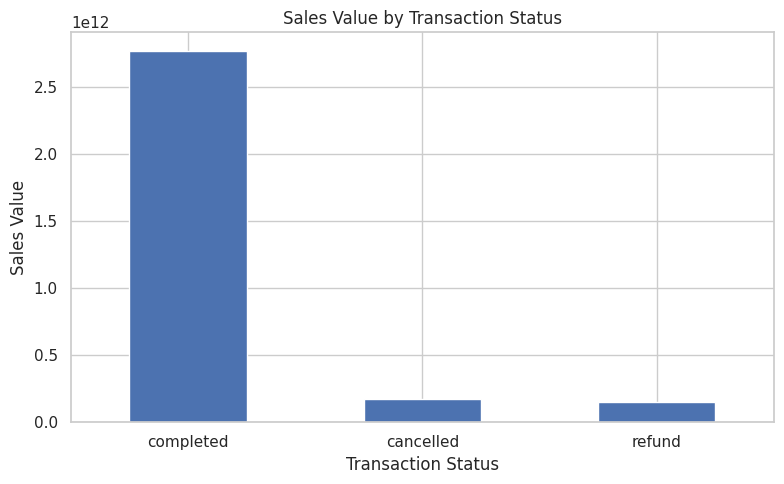

In [143]:
status_summary["sales_value"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales Value by Transaction Status")
plt.xlabel("Transaction Status")
plt.ylabel("Sales Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

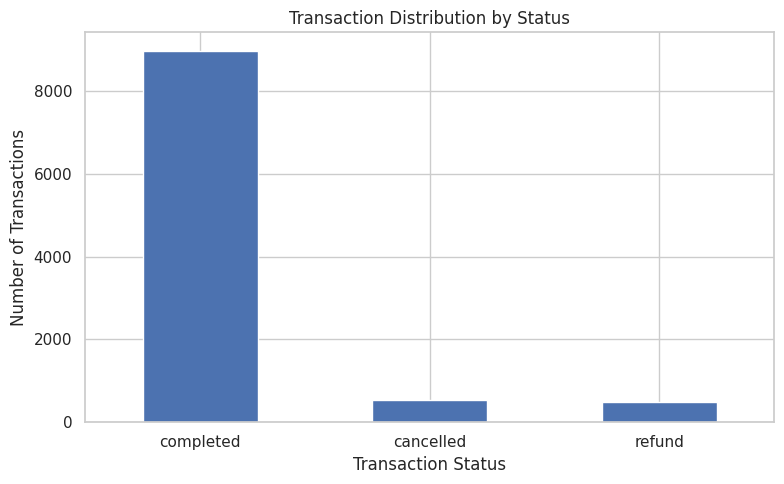

In [144]:
status_count = df["status"].value_counts()

status_count.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Transaction Distribution by Status")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 07. Revenue Drivers

### Business Question

Which categories, products, and branches contribute most to realized sales?

In [145]:
category_performance = (
    df[df["is_completed"]]
    .groupby("category")
    .agg(
        units_sold=("quantity", "sum"),
        transactions=("order_id", "count"),
        revenue=("total_sales", "sum")
    )
    .sort_values("revenue", ascending=False)
)

category_performance

,units_sold,transactions,revenue
category,,,
SUV,4273,4107,1509533000000
MPV,3658,3500,890405000000
Pickup,466,452,213717000000
City Car (EV),456,438,87919000000
Hatchback,489,469,66565000000


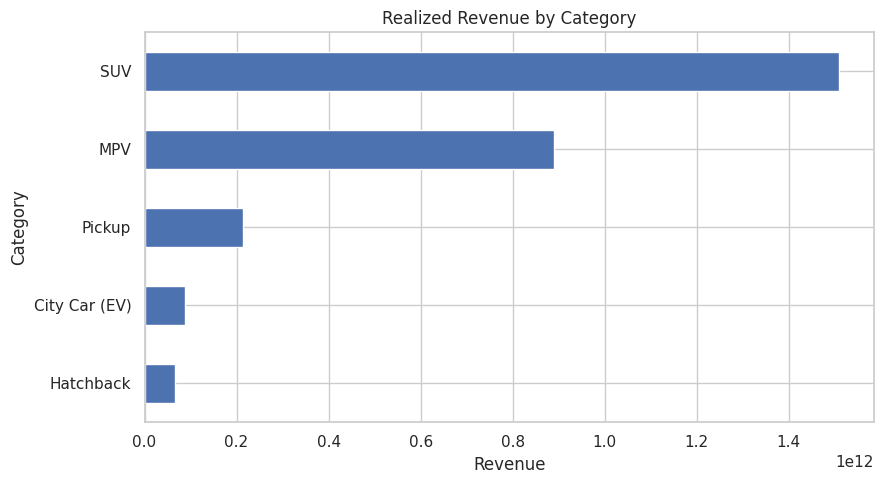

In [146]:
category_performance["revenue"].sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Realized Revenue by Category")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## 08. Product Performance

In [147]:
product_performance = (
    df[df["is_completed"]]
    .groupby("product_name")
    .agg(
        units_sold=("quantity", "sum"),
        revenue=("total_sales", "sum")
    )
    .sort_values("revenue", ascending=False)
)

product_performance.head(10)

,units_sold,revenue
product_name,,
Honda CR-V 1.5 Turbo RS,455,271822000000
Toyota Fortuner 2.4 VRZ 4x2 AT,501,263708000000
Mitsubishi Pajero Sport Dakar 4x2 AT,466,242460000000
Isuzu D-Max Double Cabin 4x4 AT,466,213717000000
Honda HR-V 1.5 E CVT,509,164833000000
Toyota Innova Zenix 2.0 V CVT,409,161190000000
Hyundai Creta Prime AT,488,128799000000
Honda BR-V 1.5 E CVT,481,123147000000
Wuling Almaz RS Pro AT,452,119807000000


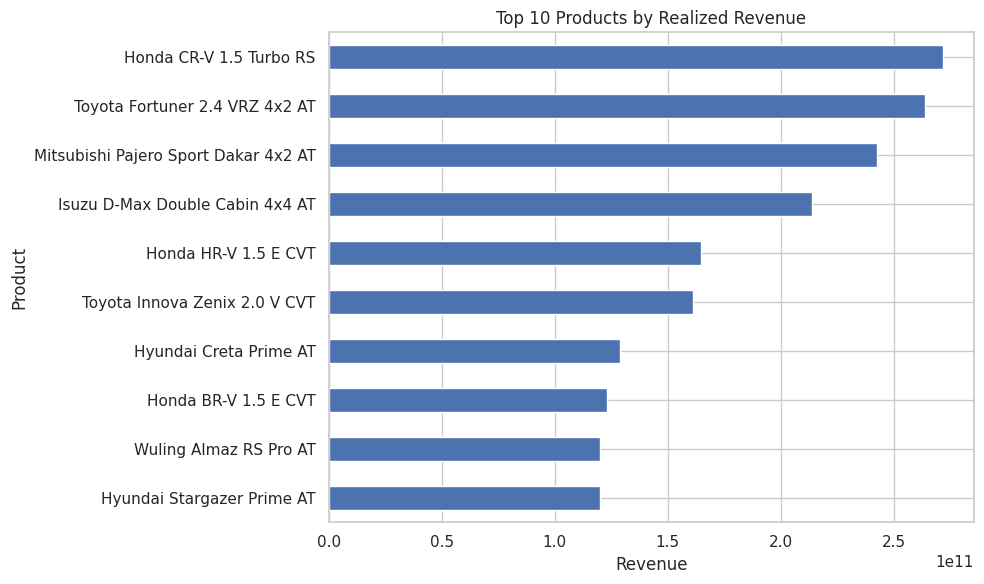

In [148]:
top_products = product_performance.head(10)

top_products["revenue"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Realized Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

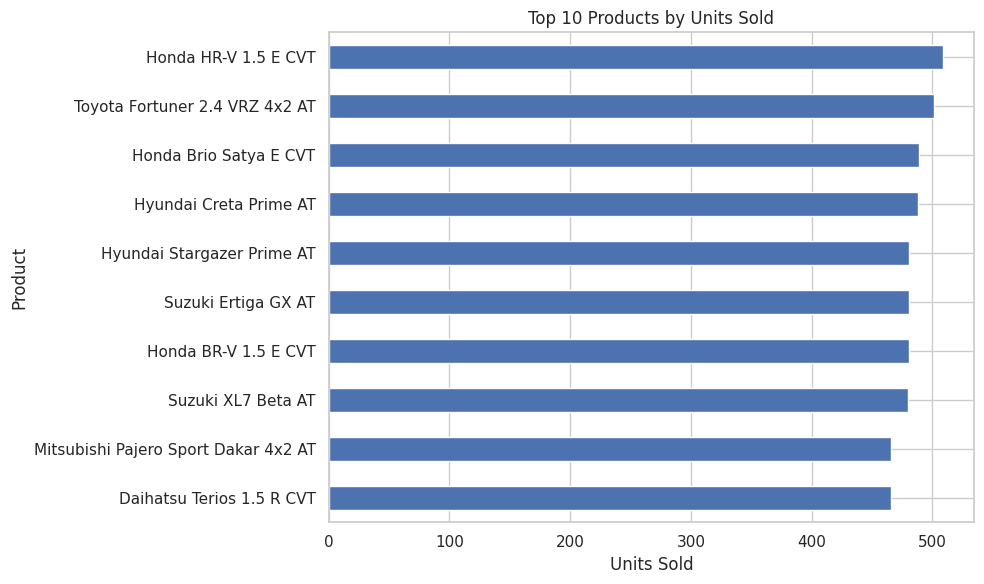

In [149]:
top_units = (
    df[df["is_completed"]]
    .groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_units.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## 09. Branch Performance

In [150]:
branch_performance = (
    df.groupby("branch")
      .agg(
          total_transactions=("order_id", "count"),
          completed_transactions=("is_completed", "sum"),
          realized_revenue=(
              "total_sales",
              lambda x: x[df.loc[x.index, "is_completed"]].sum()
          )
      )
)

branch_performance["completion_rate"] = (
    branch_performance["completed_transactions"]
    / branch_performance["total_transactions"]
    * 100
)

branch_performance.sort_values(
    "realized_revenue",
    ascending=False
)

,total_transactions,completed_transactions,realized_revenue,completion_rate
branch,,,,
Malang,1044,926,291605000000,88.70
Padang,1044,942,285888000000,90.23
Jakarta,1058,938,283701000000,88.66
Bandung,989,892,278617000000,90.19
Batam,986,893,278133000000,90.57
Palembang,981,874,277360000000,89.09
Kendari,976,882,275883000000,90.37
Semarang,967,865,267237000000,89.45
Pontianak,982,880,265419000000,89.61


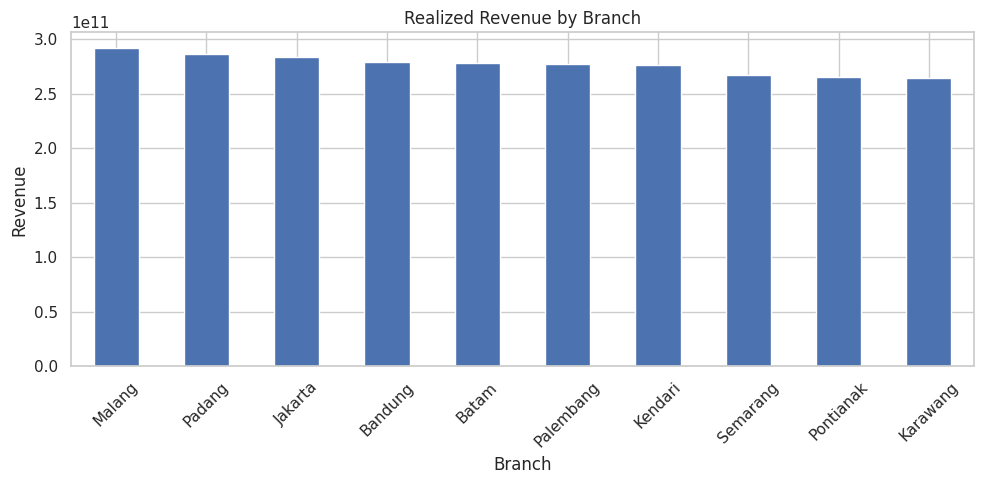

In [151]:
branch_revenue = (
    df[df["is_completed"]]
    .groupby("branch")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

branch_revenue.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Realized Revenue by Branch")
plt.xlabel("Branch")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

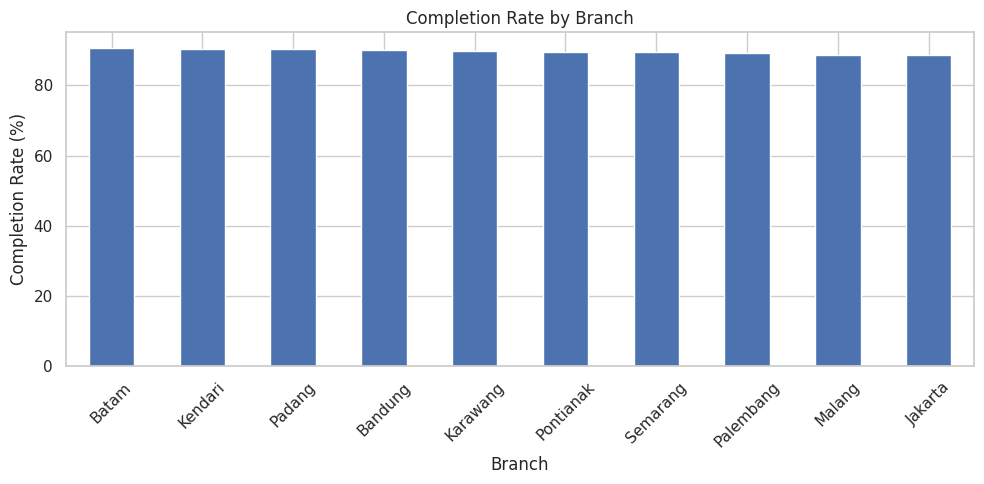

In [152]:
branch_completion = (
    branch_performance["completion_rate"]
    .sort_values(ascending=False)
)

branch_completion.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Completion Rate by Branch")
plt.xlabel("Branch")
plt.ylabel("Completion Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Branch × Category Analysis

This analysis compares category performance across branches to identify differences in product-category contribution.

In [153]:
branch_category = (
    df[df["is_completed"]]
    .groupby(["branch", "category"])
    .agg(
        units_sold=("quantity", "sum"),
        revenue=("total_sales", "sum")
    )
    .reset_index()
)

branch_category.sort_values(
    "revenue",
    ascending=False
).head(15)

,branch,category,units_sold,revenue
39,Palembang,SUV,445,157626000000
14,Jakarta,SUV,447,155749000000
29,Malang,SUV,424,154891000000
9,Batam,SUV,425,151981000000
19,Karawang,SUV,433,150498000000
24,Kendari,SUV,427,150494000000
4,Bandung,SUV,416,149455000000
44,Pontianak,SUV,428,148135000000
34,Padang,SUV,417,146655000000
49,Semarang,SUV,411,144049000000


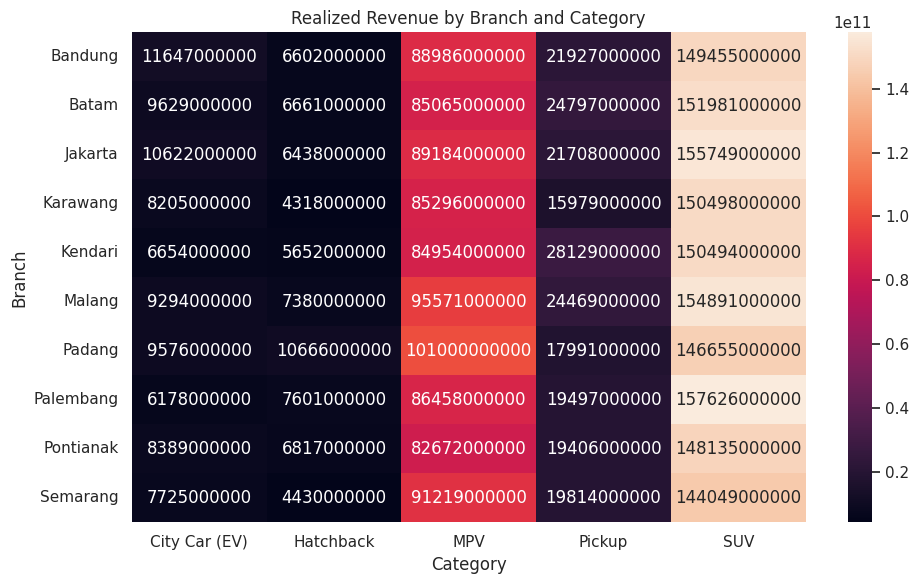

In [154]:
pivot_branch_category = branch_category.pivot(
    index="branch",
    columns="category",
    values="revenue"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot_branch_category,
    annot=True,
    fmt=".0f"
)

plt.title("Realized Revenue by Branch and Category")
plt.xlabel("Category")
plt.ylabel("Branch")
plt.tight_layout()
plt.show()

## 11. Customer Behavior

In [155]:
unique_customers = df["customer_name"].nunique()

print(f"Unique customers: {unique_customers:,}")

Unique customers: 3,977


In [156]:
customer_frequency = (
    df.groupby("customer_name")
      .size()
      .sort_values(ascending=False)
)

customer_frequency.head(10)

,0
customer_name,
Customer_392,9
Customer_57,9
Customer_4190,9
Customer_3936,9
Customer_3124,9
Customer_4258,9
Customer_323,8
Customer_2407,8
Customer_3355,8


In [157]:
customer_frequency.value_counts().sort_index().head(15)

# This helps see whether the dataset is mostly single-transaction customers
# or has meaningful repeat customers.

,count
1,1050
2,1223
3,864
4,481
5,235
6,78
7,29
8,11
9,6


## 12. Payment Behavior

In [158]:
payment_summary = (
    df[df["is_completed"]]
    .groupby("payment_type")
    .agg(
        transactions=("order_id", "count"),
        units_sold=("quantity", "sum"),
        revenue=("total_sales", "sum")
    )
    .sort_values("transactions", ascending=False)
)

payment_summary

,transactions,units_sold,revenue
payment_type,,,
Kredit,3813,3979,1397814000000
Cash,1988,2073,725454000000
Kredit + Trade In,1795,1859,362463000000
Cash + Trade In,1370,1431,282408000000


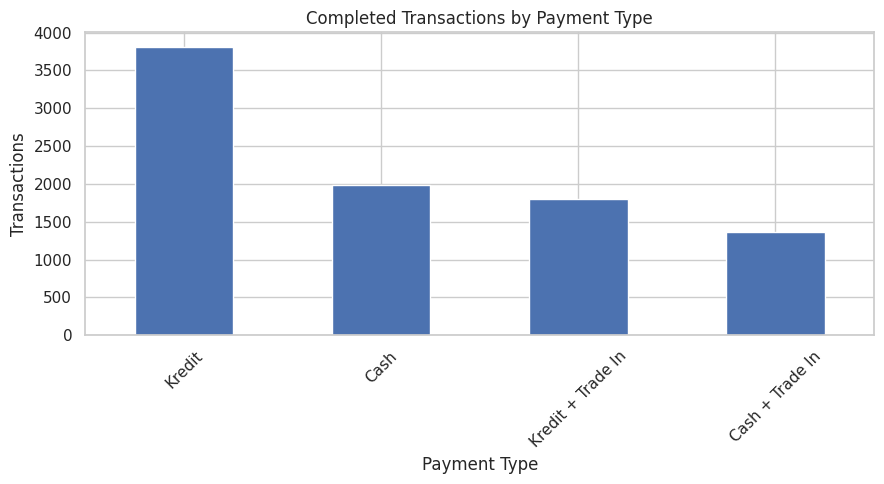

In [159]:
payment_summary["transactions"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Completed Transactions by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 13. Trade-In Analysis

### Business Questions

- How common is Trade-In?
- Which branches have the highest Trade-In usage?
- Does Trade-In behavior differ across branches?

In [160]:
tradein_summary = (
    df.groupby("trade_in_status_clean")
      .agg(
          transactions=("order_id", "count"),
          units_sold=("quantity", "sum"),
          revenue=("total_sales", "sum"),
          trade_in_value=("trade_in", "sum")
      )
      .sort_values("transactions", ascending=False)
)

tradein_summary

,transactions,units_sold,revenue,trade_in_value
trade_in_status_clean,,,,
Non Trade In,6477,6761,2371930000000,0
Trade In,3523,3672,720755000000,579307000000


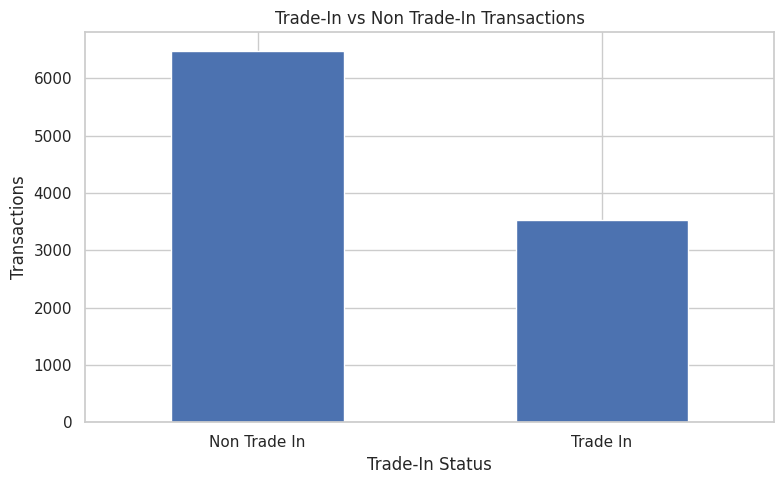

In [161]:
tradein_summary["transactions"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Trade-In vs Non Trade-In Transactions")
plt.xlabel("Trade-In Status")
plt.ylabel("Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 14. Trade-In by Branch

In [162]:
tradein_branch = (
    df.groupby("branch")
      .agg(
          trade_in_transactions=(
              "trade_in_status_clean",
              lambda x: (x == "Trade In").sum()
          ),
          total_transactions=("order_id", "count")
      )
)

tradein_branch["trade_in_percentage"] = (
    tradein_branch["trade_in_transactions"]
    / tradein_branch["total_transactions"]
    * 100
)

tradein_branch = tradein_branch.sort_values(
    "trade_in_percentage",
    ascending=False
)

tradein_branch

,trade_in_transactions,total_transactions,trade_in_percentage
branch,,,
Karawang,366,973,37.62
Jakarta,391,1058,36.96
Kendari,350,976,35.86
Pontianak,350,982,35.64
Semarang,342,967,35.37
Bandung,348,989,35.19
Batam,342,986,34.69
Palembang,334,981,34.05
Malang,352,1044,33.72


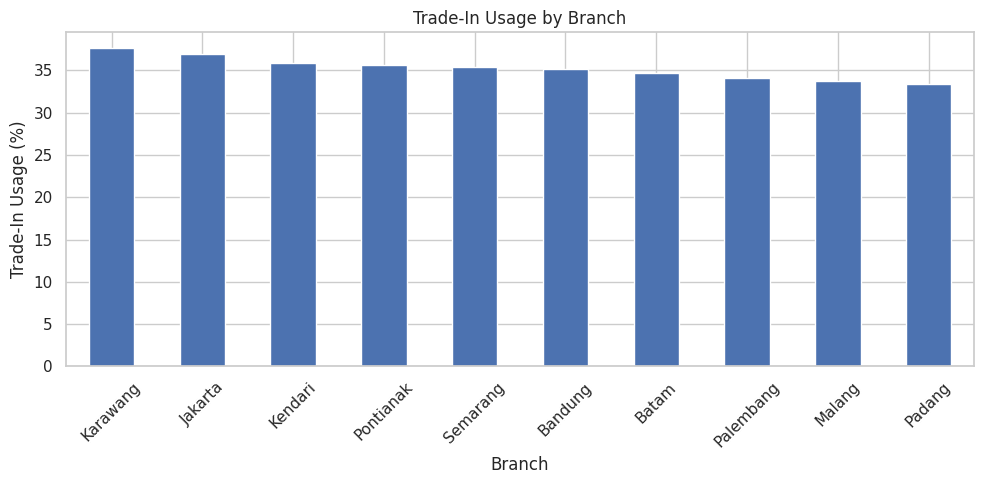

In [163]:
tradein_branch["trade_in_percentage"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Trade-In Usage by Branch")
plt.xlabel("Branch")
plt.ylabel("Trade-In Usage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 15. Bandung Trade-In Analysis

This is one of the questions from our earlier project, so it's included explicitly.

In [164]:
bandung_tradein = tradein_branch.loc["Bandung"]

print(
    f"Bandung Trade-In Transactions: "
    f"{bandung_tradein['trade_in_transactions']:,.0f}"
)

print(
    f"Bandung Total Transactions: "
    f"{bandung_tradein['total_transactions']:,.0f}"
)

print(
    f"Bandung Trade-In Usage: "
    f"{bandung_tradein['trade_in_percentage']:.2f}%"
)

Bandung Trade-In Transactions: 348
Bandung Total Transactions: 989
Bandung Trade-In Usage: 35.19%


In [165]:
tradein_comparison = (
    tradein_branch[
        ["trade_in_percentage"]
    ]
    .sort_values(
        "trade_in_percentage",
        ascending=False
    )
)

tradein_comparison

# We don't make up a recommendation about Bandung here.
# We first check whether Bandung is actually high or low compared to other branches.

,trade_in_percentage
branch,
Karawang,37.62
Jakarta,36.96
Kendari,35.86
Pontianak,35.64
Semarang,35.37
Bandung,35.19
Batam,34.69
Palembang,34.05
Malang,33.72


# 16. Sales Trend

### Business Question

How does showroom sales performance change over time?

In [166]:
monthly_transactions = (
    df.groupby("month_date")
      .size()
)

monthly_transactions

,0
month_date,
2025-01-01,820
2025-02-01,767
2025-03-01,852
2025-04-01,830
2025-05-01,868
2025-06-01,767
2025-07-01,875
2025-08-01,877
2025-09-01,796


In [167]:
monthly_units = (
    df[df["is_completed"]]
    .groupby("month_date")["quantity"]
    .sum()
)

monthly_units

,quantity
month_date,
2025-01-01,770
2025-02-01,739
2025-03-01,782
2025-04-01,770
2025-05-01,797
2025-06-01,719
2025-07-01,839
2025-08-01,826
2025-09-01,737


In [168]:
monthly_revenue = (
    df[df["is_completed"]]
    .groupby("month_date")["total_sales"]
    .sum()
)

monthly_revenue

,total_sales
month_date,
2025-01-01,227262000000
2025-02-01,217287000000
2025-03-01,237391000000
2025-04-01,229691000000
2025-05-01,236727000000
2025-06-01,212314000000
2025-07-01,249720000000
2025-08-01,249727000000
2025-09-01,217041000000


## 17. Monthly Units Sold Chart

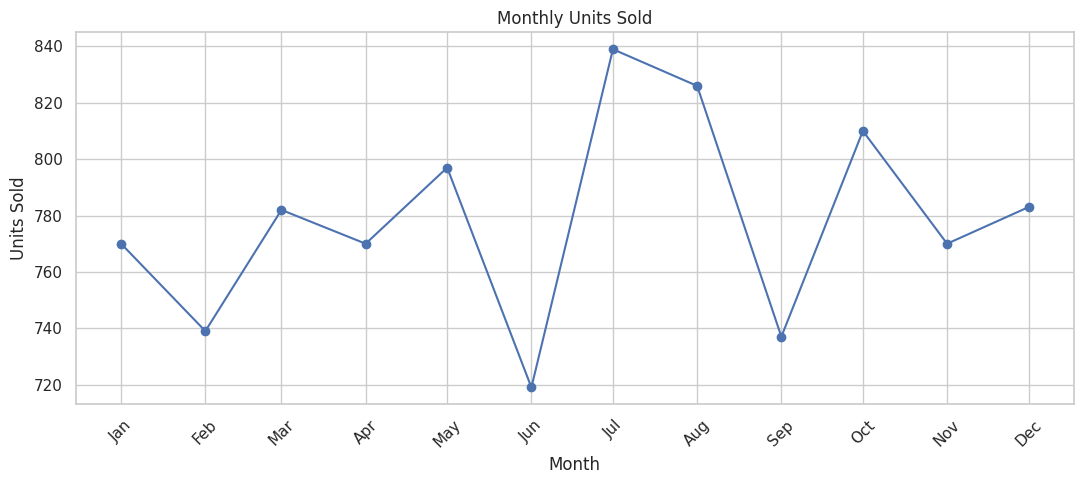

In [169]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_units.index,
    monthly_units.values,
    marker="o"
)

plt.title("Monthly Units Sold")
plt.xlabel("Month")
plt.ylabel("Units Sold")

plt.xticks(
    monthly_units.index,
    monthly_units.index.strftime("%b"),
    rotation=45
)

plt.tight_layout()
plt.show()

## 18. Monthly Revenue Chart

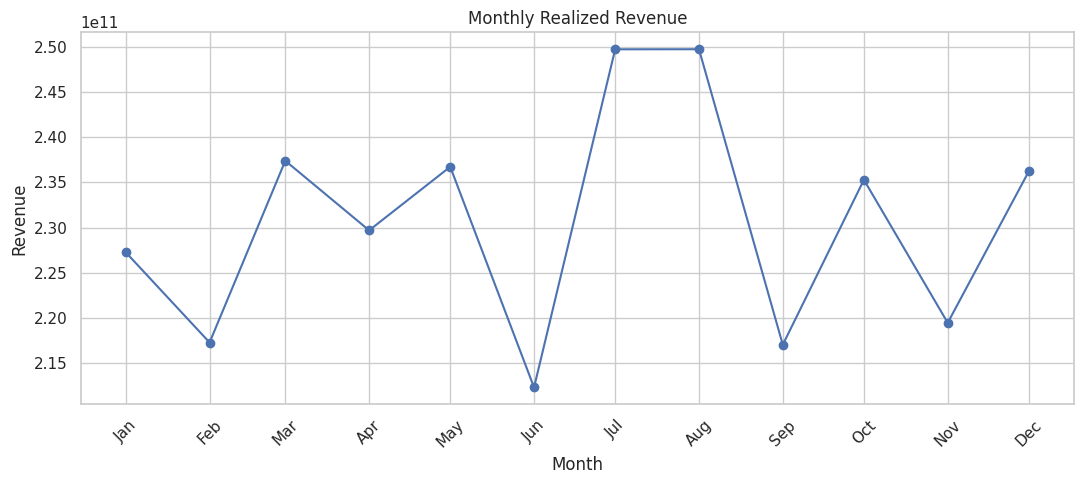

In [170]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Realized Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(
    monthly_revenue.index,
    monthly_revenue.index.strftime("%b"),
    rotation=45
)

plt.tight_layout()
plt.show()

## 19. Monthly Completion Rate

In [171]:
monthly_completion = (
    df.groupby("month_date")
      .agg(
          total_transactions=("order_id", "count"),
          completed_transactions=("is_completed", "sum")
      )
)

monthly_completion["completion_rate"] = (
    monthly_completion["completed_transactions"]
    / monthly_completion["total_transactions"]
    * 100
)

monthly_completion

,total_transactions,completed_transactions,completion_rate
month_date,,,
2025-01-01,820,739,90.12
2025-02-01,767,695,90.61
2025-03-01,852,757,88.85
2025-04-01,830,742,89.40
2025-05-01,868,772,88.94
2025-06-01,767,696,90.74
2025-07-01,875,796,90.97
2025-08-01,877,789,89.97
2025-09-01,796,712,89.45


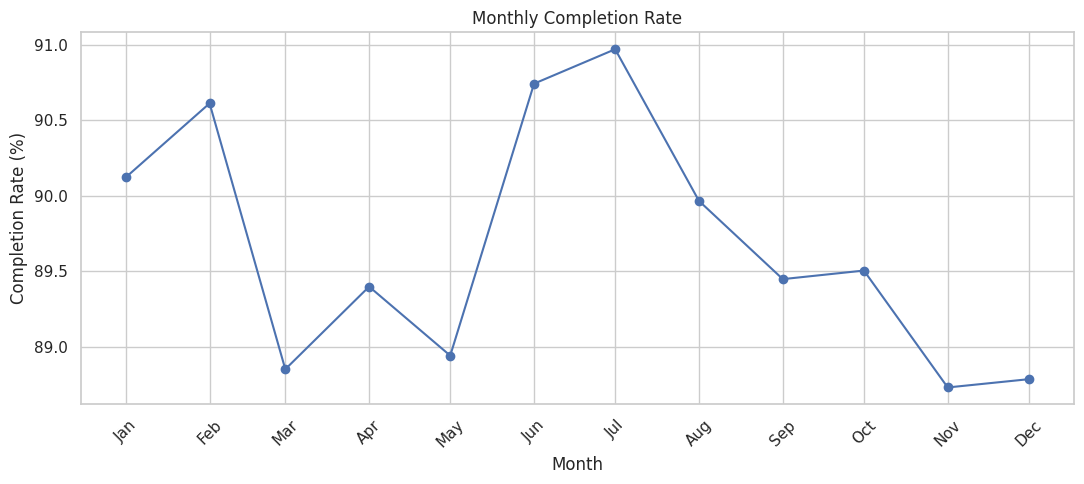

In [172]:
plt.figure(figsize=(11, 5))

plt.plot(
    monthly_completion.index,
    monthly_completion["completion_rate"],
    marker="o"
)

plt.title("Monthly Completion Rate")
plt.xlabel("Month")
plt.ylabel("Completion Rate (%)")

plt.xticks(
    monthly_completion.index,
    monthly_completion.index.strftime("%b"),
    rotation=45
)

plt.tight_layout()
plt.show()

## 20. Transaction Status Trend

In [173]:
status_monthly = (
    df.groupby(
        ["month_date", "status"]
    )
    .size()
    .unstack(fill_value=0)
)

status_monthly

status,cancelled,completed,refund
month_date,,,
2025-01-01,42,739,39
2025-02-01,35,695,37
2025-03-01,49,757,46
2025-04-01,46,742,42
2025-05-01,51,772,45
2025-06-01,34,696,37
2025-07-01,41,796,38
2025-08-01,46,789,42
2025-09-01,48,712,36


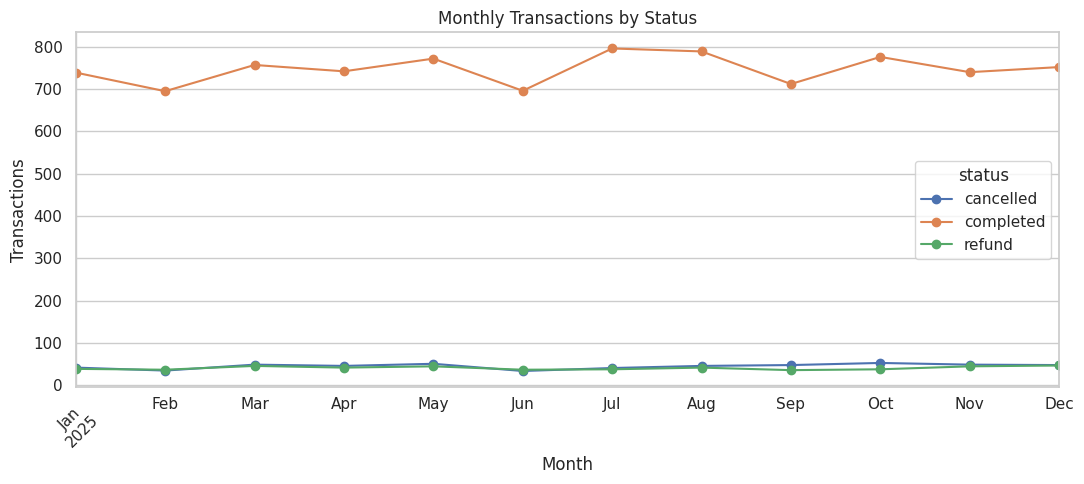

In [174]:
status_monthly.plot(
    figsize=(11, 5),
    marker="o"
)

plt.title("Monthly Transactions by Status")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 21. Additional EDA — Sales Price Distribution

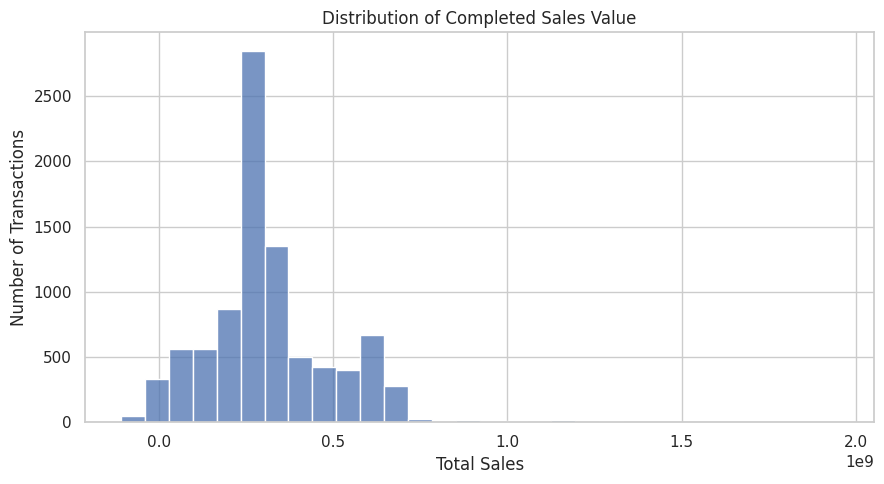

In [175]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df[df["is_completed"]],
    x="total_sales",
    bins=30
)

plt.title("Distribution of Completed Sales Value")
plt.xlabel("Total Sales")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

## 22. Category × Sales Value

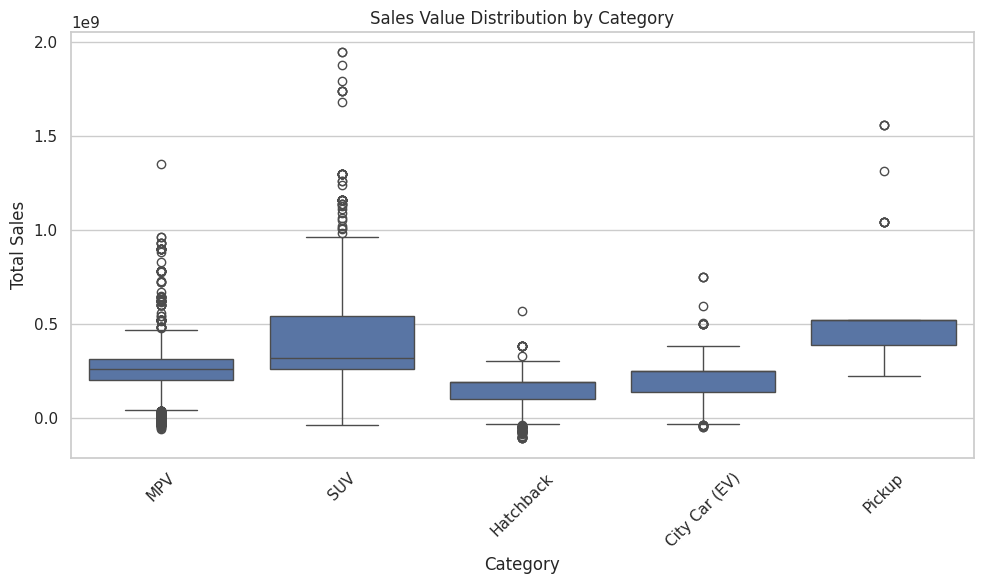

In [176]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[df["is_completed"]],
    x="category",
    y="total_sales"
)

plt.title("Sales Value Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 23. Quantity Analysis

Since the dataset has a `quantity` field, we also check whether any transactions have quantity > 1.

In [177]:
df["quantity"].value_counts().sort_index()

,count
quantity,
1,9638
2,291
3,71


In [178]:
quantity_summary = (
    df.groupby("quantity")
      .agg(
          transactions=("order_id", "count"),
          revenue=("total_sales", "sum")
      )
)

quantity_summary

,transactions,revenue
quantity,,
1,9638,2835293000000
2,291,184311000000
3,71,73081000000


## 24. Revenue Contribution

Useful for pinning down revenue drivers more rigorously.

In [179]:
category_contribution = category_performance.copy()

category_contribution["revenue_contribution_pct"] = (
    category_contribution["revenue"]
    / category_contribution["revenue"].sum()
    * 100
)

category_contribution

,units_sold,transactions,revenue,revenue_contribution_pct
category,,,,
SUV,4273,4107,1509533000000,54.53
MPV,3658,3500,890405000000,32.17
Pickup,466,452,213717000000,7.72
City Car (EV),456,438,87919000000,3.18
Hatchback,489,469,66565000000,2.40


## 25. Pareto Product Analysis

To show which products contribute most to revenue:

In [180]:
product_pareto = product_performance.copy()

product_pareto["revenue_pct"] = (
    product_pareto["revenue"]
    / product_pareto["revenue"].sum()
    * 100
)

product_pareto["cumulative_revenue_pct"] = (
    product_pareto["revenue_pct"].cumsum()
)

product_pareto.head(15)

,units_sold,revenue,revenue_pct,cumulative_revenue_pct
product_name,,,,
Honda CR-V 1.5 Turbo RS,455,271822000000,9.82,9.82
Toyota Fortuner 2.4 VRZ 4x2 AT,501,263708000000,9.53,19.35
Mitsubishi Pajero Sport Dakar 4x2 AT,466,242460000000,8.76,28.11
Isuzu D-Max Double Cabin 4x4 AT,466,213717000000,7.72,35.83
Honda HR-V 1.5 E CVT,509,164833000000,5.95,41.78
Toyota Innova Zenix 2.0 V CVT,409,161190000000,5.82,47.60
Hyundai Creta Prime AT,488,128799000000,4.65,52.26
Honda BR-V 1.5 E CVT,481,123147000000,4.45,56.71
Wuling Almaz RS Pro AT,452,119807000000,4.33,61.03


In [181]:
top_80_products = product_pareto[
    product_pareto["cumulative_revenue_pct"] <= 80
]

print(
    f"Products contributing up to 80% of realized revenue: "
    f"{len(top_80_products)}"
)

print(
    f"Total products: "
    f"{len(product_pareto)}"
)

# This can be a strong insight if the result is significant.

Products contributing up to 80% of realized revenue: 13
Total products: 20


## 26. Final Summary Tables

In [182]:
print("=== REVENUE REALIZATION ===")
print(f"Reported Sales : Rp {reported_sales:,.0f}")
print(f"Realized Sales : Rp {realized_sales:,.0f}")
print(f"Sales Gap      : Rp {sales_gap:,.0f}")
print(f"Realization Rate: {realization_rate:.2f}%")

=== REVENUE REALIZATION ===
Reported Sales : Rp 3,092,685,000,000
Realized Sales : Rp 2,768,139,000,000
Sales Gap      : Rp 324,546,000,000
Realization Rate: 89.51%


In [183]:
print("=== TOP CATEGORY ===")
print(category_performance.head(3))

=== TOP CATEGORY ===
          units_sold  transactions        revenue
category                                         
SUV             4273          4107  1509533000000
MPV             3658          3500   890405000000
Pickup           466           452   213717000000


In [184]:
print("=== TOP BRANCH ===")
print(branch_performance.sort_values(
    "realized_revenue",
    ascending=False
).head(5))

=== TOP BRANCH ===
         total_transactions  completed_transactions  realized_revenue  \
branch                                                                  
Malang                 1044                     926      291605000000   
Padang                 1044                     942      285888000000   
Jakarta                1058                     938      283701000000   
Bandung                 989                     892      278617000000   
Batam                   986                     893      278133000000   

         completion_rate  
branch                    
Malang             88.70  
Padang             90.23  
Jakarta            88.66  
Bandung            90.19  
Batam              90.57  


In [185]:
print("=== TOP PRODUCTS ===")
print(product_performance.head(10))

=== TOP PRODUCTS ===
                                      units_sold       revenue
product_name                                                  
Honda CR-V 1.5 Turbo RS                      455  271822000000
Toyota Fortuner 2.4 VRZ 4x2 AT               501  263708000000
Mitsubishi Pajero Sport Dakar 4x2 AT         466  242460000000
Isuzu D-Max Double Cabin 4x4 AT              466  213717000000
Honda HR-V 1.5 E CVT                         509  164833000000
Toyota Innova Zenix 2.0 V CVT                409  161190000000
Hyundai Creta Prime AT                       488  128799000000
Honda BR-V 1.5 E CVT                         481  123147000000
Wuling Almaz RS Pro AT                       452  119807000000
Hyundai Stargazer Prime AT                   481  119778000000


In [186]:
print("=== TRADE-IN BY BRANCH ===")
print(tradein_branch)

=== TRADE-IN BY BRANCH ===
           trade_in_transactions  total_transactions  trade_in_percentage
branch                                                                   
Karawang                     366                 973                37.62
Jakarta                      391                1058                36.96
Kendari                      350                 976                35.86
Pontianak                    350                 982                35.64
Semarang                     342                 967                35.37
Bandung                      348                 989                35.19
Batam                        342                 986                34.69
Palembang                    334                 981                34.05
Malang                       352                1044                33.72
Padang                       348                1044                33.33


## 27. Key Findings


# Key Findings

## 1. Revenue Realization

- Reported sales reached Rp 3,092,685,000,000
- Realized sales from completed transactions reached Rp 2,768,139,000,000
- Revenue realization rate was 89.51%.
- The remaining gap (Rp 324,546,000,000) was associated with cancelled and refund transactions — cancelled transactions alone accounted for Rp 169,932,000,000 (542 transactions) and refunds for Rp 154,614,000,000 (492 transactions).

## 2. Revenue Drivers

- The highest-performing category was SUV, contributing Rp 1,509,533,000,000 in realized revenue (54.53% of total realized revenue).
- The top product by realized revenue was the Honda CR-V 1.5 Turbo RS, with Rp 271,822,000,000 from 455 units sold.
- Malang branch generated the highest realized revenue (Rp 291,605,000,000).

## 3. Branch Performance

- Malang branch recorded the highest realized revenue (Rp 291,605,000,000).
- Batam branch recorded the highest completion rate (90.57%).
- Revenue leadership and completion leadership were NOT concentrated in the same branch — Malang topped revenue but had the lowest completion rate among the top 5 branches (88.70%), while Batam led completion but ranked 5th in revenue.

## 4. Customer & Transaction Behavior

- The most common payment type was Kredit, used in 3,813 completed transactions (Rp 1,397,814,000,000 in revenue) — more than any other payment method, including Kredit + Trade In (1,795 transactions).
- The dataset contained 3,977 unique customers.
- The most frequently purchased product was the Honda HR-V 1.5 E CVT, with 509 units sold among completed transactions (557 occurrences overall, the highest of any product).

## 5. Trade-In

- Trade-In represented 35.23% of transactions (3,523 of 10,000 total transactions).
- Karawang branch had the highest Trade-In usage (37.62%).
- Bandung recorded 35.19% Trade-In usage — essentially in line with the overall average (35.23%), not a standout high or low.

## 6. Sales Trend

- The highest monthly realized revenue occurred in August 2025 (Rp 249,727,000,000), narrowly ahead of July (Rp 249,720,000,000).
- The highest number of units sold occurred in July 2025 (839 units).
- Monthly completion rate ranged from 88.73% (November) to 90.97% (July).

# 28. Business Implications

Based on the exploratory analysis:

1. **Revenue Realization**
   Management should monitor cancelled and refund transactions because reported sales do not necessarily translate directly into realized sales.

2. **Revenue Drivers**
   High-contributing categories and products should remain a priority for inventory and sales planning.

3. **Branch Performance**
   Branches should be evaluated using both revenue and completion rate rather than transaction volume alone.

4. **Trade-In Strategy**
   Branch-level differences in Trade-In adoption can be used to identify locations where Trade-In programs may have stronger potential.

5. **Sales Trend**
   Monthly sales patterns can support sales target planning and resource allocation.